# Fase C — Critério cinético de estado

O notebook 02 agrupou os 12 diedros em K=4 estados pela geometria. Aqui a
pergunta é outra (PLANO.md §4): **esses estados são metaestáveis?** Um estado
só é metaestável se a molécula fica nele por tempo longo comparado ao tempo de
trânsito, e isso é propriedade da dinâmica, não da forma.

Roteiro:

0. uma propriedade dos dados que condiciona tudo o que vem depois
1. os estados de referência (K=4) e a sua reprodutibilidade
2. tempos de residência e escalas de tempo implícitas: os 4 estados passam no teste cinético?
3. microestados finos: quantos processos lentos a trajetória tem de fato?
4. o que é o processo lento, fisicamente
5. a trajetória de 300 K: KNN (tarefa opcional 11) e agrupamento próprio
6. resposta à Questão 7

Todo o tempo é medido em **frames** (1 frame = 10 ps). As funções vêm de
[`molsim/kinetics.py`](../molsim/kinetics.py), testadas em
[`tests/test_kinetics.py`](../tests/test_kinetics.py) contra cadeias de Markov
com escala de tempo conhecida.

In [1]:
import sys
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors

from molsim import kinetics as kin
from molsim.data import (DIHEDRAL_NAMES, dihedrals, load_features, ramachandran_region,
                         read_xyz, state_name)
from molsim.kmeans_variants import best_of, canonical_states, kmeans_periodic, match_states

FIGS = REPO / "figs"
DT_PS = 10.0
K = 4
CORES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # uma cor fixa por estado, nesta ordem
CINZA = "#8a8984"
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "lines.linewidth": 2, "font.size": 11,
})

df500 = load_features(REPO / "notebooks" / "trajectory.xyz")
df300 = load_features(REPO / "notebooks" / "trajectory_300K.xyz")
X5 = df500[DIHEDRAL_NAMES].values
X3 = df300[DIHEDRAL_NAMES].values
RESIDUOS = [f"Ala{i}" for i in range(1, 7)]
print(f"500 K: {len(X5)} frames ({len(X5) * DT_PS / 1000:.0f} ns)   "
      f"300 K: {len(X3)} frames ({len(X3) * DT_PS / 1000:.0f} ns)")

500 K: 2000 frames (20 ns)   300 K: 1000 frames (10 ns)


## 0. Antes dos estados: uma ligação peptídica *cis*

O ângulo ω = Cα(i)–C(i)–N(i+1)–Cα(i+1) mede a ligação peptídica entre dois
resíduos vizinhos. Numa ligação *trans* (a regra em peptídeos sem prolina)
|ω| ≈ 180° e os dois Cα ficam a ~3,8 Å; numa *cis*, |ω| ≈ 0° e a distância cai
para ~2,9 Å.

In [2]:
# omega entre Ala(i) e Ala(i+1): CA(i) - C(i) - N(i+1) - CA(i+1)
OMEGA_ATOMS = [(3 + 6 * i + 2, 3 + 6 * i + 4, 3 + 6 * i + 6, 3 + 6 * i + 8) for i in range(5)]

linhas = []
for temp, arq in [("500 K", "trajectory.xyz"), ("300 K", "trajectory_300K.xyz")]:
    _, coords = read_xyz(REPO / "notebooks" / arq)
    omega = np.abs(dihedrals(coords, OMEGA_ATOMS))
    for i, (a, _, _, d) in enumerate(OMEGA_ATOMS):
        linhas.append({
            "T": temp, "ligação": f"Ala{i + 1}–Ala{i + 2}",
            "|ω| médio (°)": omega[:, i].mean(),
            "fração cis": (omega[:, i] < 90).mean(),
            "Cα–Cα (Å)": np.linalg.norm(coords[:, a] - coords[:, d], axis=1).mean(),
        })
pd.DataFrame(linhas).round(2)

,T,ligação,|ω| médio (°),fração cis,Cα–Cα (Å)
0,500 K,Ala1–Ala2,175.96,0.0,3.80
1,500 K,Ala2–Ala3,174.60,0.0,3.80
2,500 K,Ala3–Ala4,4.30,1.0,2.96
3,500 K,Ala4–Ala5,174.62,0.0,3.81
4,500 K,Ala5–Ala6,175.63,0.0,3.81
5,300 K,Ala1–Ala2,176.00,0.0,3.80
6,300 K,Ala2–Ala3,176.92,0.0,3.78
7,300 K,Ala3–Ala4,2.65,1.0,2.95
8,300 K,Ala4–Ala5,170.20,0.0,3.80
9,300 K,Ala5–Ala6,174.27,0.0,3.81


In [3]:
def ocupacao(X):
    # fração do tempo que cada resíduo passa em cada região de Ramachandran
    reg = ramachandran_region(X[:, 0::2], X[:, 1::2])
    return pd.DataFrame({r: (reg == r).mean(axis=0) for r in ["α", "β", "P", "L"]}, index=RESIDUOS)

pd.concat({"500 K": ocupacao(X5), "300 K": ocupacao(X3)}, axis=1).round(2)

500 K                   300 K                 
         α     β     P     L     α     β     P    L
Ala1  0.16  0.18  0.60  0.06  0.48  0.02  0.50  0.0
Ala2  0.16  0.15  0.52  0.17  0.05  0.02  0.93  0.0
Ala3  0.00  0.16  0.83  0.00  0.00  0.00  1.00  0.0
Ala4  0.25  0.73  0.02  0.00  0.61  0.39  0.00  0.0
Ala5  0.31  0.12  0.27  0.30  0.96  0.02  0.01  0.0
Ala6  0.19  0.17  0.57  0.07  0.30  0.19  0.51  0.0

**A ligação Ala3–Ala4 é *cis* em todos os frames, nas duas temperaturas**; as
outras quatro são *trans*. A consequência aparece na tabela de ocupação: os
dois resíduos que a ligação *cis* une ficam restritos — Ala3 nunca sai da
região estendida (β ou PPII) e Ala4 nunca chega a α_L, nem a 500 K, enquanto Ala2 e Ala5
passam boa parte do tempo em α_L.

Isso é propriedade dos dados fornecidos, não da análise: a barreira de
isomerização *cis*/*trans* da ligação peptídica é alta (da ordem de
20 kcal/mol) e não é cruzada em 20 ns, então a configuração deve ter vindo da
estrutura inicial. Duas implicações para o relatório:

- os estados encontrados são os de um hexâmero **com uma ligação *cis* no
  meio**, e não os de um Ace-(Ala)₆-NH₂ todo *trans*;
- uma simulação própria todo-*trans* (Fase D, agora trabalho futuro) não seria
  diretamente comparável a estas trajetórias sem levar isso em conta.

Letras usadas nos nomes dos estados, um resíduo por letra, de Ala1 a Ala6:
**α** = α_R; **β** e **P** = região estendida, β (φ < −100°) e PPII
(φ ≥ −100°); **L** = α_L (φ > 0).

## 1. Os estados de referência (K=4)

`canonical_states` roda a variante `corda` (a única coerente, notebook 02) com
50 inicializações a partir da semente 0, fica com a de menor objetivo e numera
os estados por população. É determinística: todo notebook que falar "dos
estados" chama esta função.

In [4]:
can = canonical_states(X5, k=K)
lab5 = can.labels
nomes = [state_name(c) for c in can.centers]

pops = kin.populations(lab5, K)
dG = kin.free_energy(pops, temperature=500.0)
boot = kin.block_bootstrap(lab5, lambda l: kin.free_energy(kin.populations(l, K), 500.0),
                           n_blocks=10, n_boot=1000)
dG_lo, dG_hi = np.percentile(boot, [2.5, 97.5], axis=0)
T1 = kin.transition_matrix(kin.count_matrix(lab5, lag=1, n_states=K), reversible=False)

tabela_k4 = pd.DataFrame({
    "nome": nomes, "população": pops,
    "ΔG (kcal/mol)": dG, "ΔG IC95 inf": dG_lo, "ΔG IC95 sup": dG_hi,
    "P(permanecer, 10 ps)": np.diag(T1),
})
tabela_k4.round(3)

,nome,população,ΔG (kcal/mol),ΔG IC95 inf,ΔG IC95 sup,"P(permanecer, 10 ps)"
0,PPPβPP,0.290,-0.000,-0.000,0.545,0.609
1,PPPααP,0.288,0.009,-0.000,0.730,0.779
2,PLPβLα,0.283,0.024,-0.000,0.755,0.881
3,ββPβββ,0.140,0.727,0.574,1.348,0.401


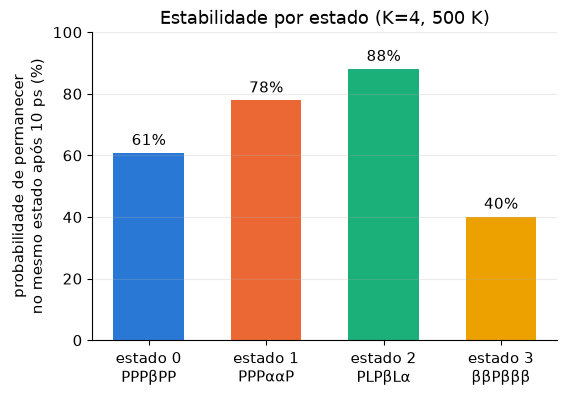

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
barras = ax.bar(range(K), 100 * np.diag(T1), color=CORES, width=0.6)
ax.bar_label(barras, fmt="%.0f%%", padding=3)
ax.set_xticks(range(K), [f"estado {i}\n{n}" for i, n in enumerate(nomes)])
ax.set_ylabel("probabilidade de permanecer\nno mesmo estado após 10 ps (%)")
ax.set_ylim(0, 100)
ax.grid(axis="x", visible=False)
ax.set_title(f"Estabilidade por estado (K={K}, 500 K)")
fig.savefig(FIGS / "estabilidade_estados.png")
plt.show()

### 1.1 Quão reprodutível é essa partição?

Rodamos a mesma variante com 50 sementes, uma inicialização cada, e alinhamos
cada resultado aos estados de referência pelos centroides (algoritmo húngaro,
`match_states`). Se a partição fosse robusta, todas as sementes dariam os
mesmos números.

In [6]:
objetivos, pop_s, perm_s = [], [], []
for s in range(50):
    r = kmeans_periodic(X5, K, "corda", max_iter=200, seed=s)
    perm = match_states(can.centers, r.centers)  # r.centers[perm[i]] <-> estado i
    novo = np.empty(K, dtype=int)
    novo[perm] = np.arange(K)
    l = novo[r.labels]
    objetivos.append(r.objective_history[-1])
    pop_s.append(kin.populations(l, K))
    perm_s.append(np.diag(kin.transition_matrix(kin.count_matrix(l, 1, K), reversible=False)))
objetivos, pop_s, perm_s = map(np.array, (objetivos, pop_s, perm_s))

n_minimos = np.unique(objetivos.round(3)).size
frac_melhor = np.isclose(objetivos, objetivos.min()).mean()
print(f"{n_minimos} mínimos locais distintos em 50 sementes; "
      f"{frac_melhor:.0%} das sementes chegam ao de menor objetivo")
pd.DataFrame({"nome": nomes,
              "população mín": pop_s.min(0), "população máx": pop_s.max(0),
              "P(permanecer) mín": perm_s.min(0), "P(permanecer) máx": perm_s.max(0)}).round(2)

43 mínimos locais distintos em 50 sementes; 6% das sementes chegam ao de menor objetivo


,nome,população mín,população máx,P(permanecer) mín,P(permanecer) máx
0,PPPβPP,0.07,0.64,0.46,0.94
1,PPPααP,0.07,0.63,0.38,0.96
2,PLPβLα,0.07,0.31,0.46,0.93
3,ββPβββ,0.09,0.57,0.40,0.91


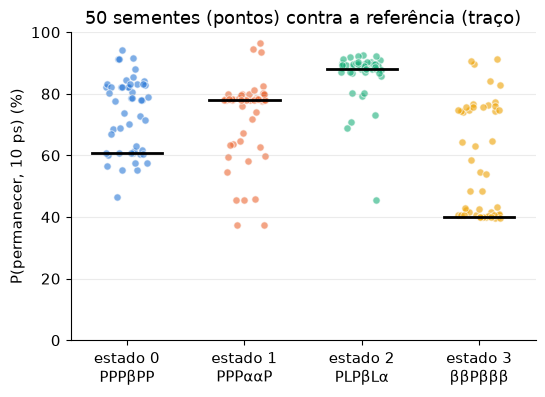

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
rng = np.random.default_rng(0)
for i in range(K):
    x = i + rng.uniform(-0.18, 0.18, len(perm_s))
    ax.scatter(x, 100 * perm_s[:, i], s=28, color=CORES[i], alpha=0.6,
               edgecolor="white", linewidth=0.8)
    ax.plot([i - 0.3, i + 0.3], [100 * T1[i, i]] * 2, color="black", lw=2)
ax.set_xticks(range(K), [f"estado {i}\n{n}" for i, n in enumerate(nomes)])
ax.set_ylabel("P(permanecer, 10 ps) (%)")
ax.set_ylim(0, 100)
ax.grid(axis="x", visible=False)
ax.set_title("50 sementes (pontos) contra a referência (traço)")
fig.savefig(FIGS / "sementes_k4.png")
plt.show()

A mesma variante, nos mesmos dados, chega a dezenas de partições diferentes, e
a estabilidade atribuída a um mesmo estado varia de "passageiro" a "quase
permanente" conforme a semente. Isso explica a discordância entre o texto, a
figura e a saída da seção de energia livre do notebook 02: aquela seção usava
uma rodada única com `random.sample` sem semente, e cada execução caía num
mínimo diferente.

É também o primeiro indício da §4: se o número de um estado, a sua população e
a sua estabilidade dependem da inicialização, **o critério geométrico sozinho
não define os estados**. A partir daqui, só a partição de referência é usada.

## 2. Os 4 estados passam no teste cinético?

### 2.1 Tempos de residência

Duração de cada visita ininterrupta a um estado. A primeira e a última visita
da trajetória são descartadas, porque foram cortadas pelo início e pelo fim da
simulação.

In [8]:
dw = kin.dwell_times(lab5, K)
residencia = pd.DataFrame({
    "nome": nomes,
    "visitas": [len(d) for d in dw],
    "média (frames)": [d.mean() for d in dw],
    "mediana (frames)": [np.median(d) for d in dw],
    "máx (frames)": [d.max() for d in dw],
})
residencia["média (ps)"] = residencia["média (frames)"] * DT_PS
residencia.round(1)

,nome,visitas,média (frames),mediana (frames),máx (frames),média (ps)
0,PPPβPP,227,2.6,2.0,18,25.6
1,PPPααP,126,4.5,3.0,27,45.3
2,PLPβLα,67,8.3,2.0,107,82.8
3,ββPβββ,167,1.7,1.0,9,16.7


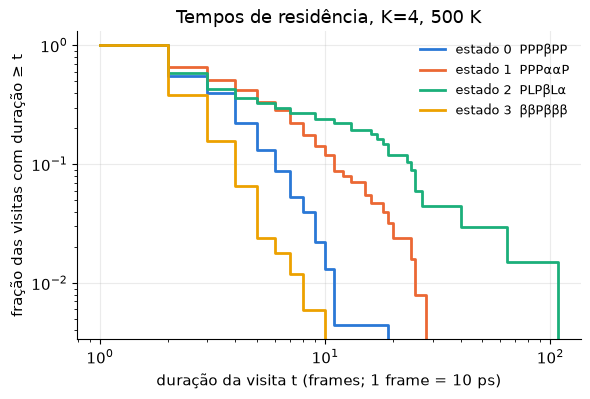

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 4))
for i, d in enumerate(dw):
    t = np.arange(1, d.max() + 2)
    sobrevive = [(d >= ti).mean() for ti in t]
    ax.step(t, sobrevive, where="post", color=CORES[i], label=f"estado {i}  {nomes[i]}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("duração da visita t (frames; 1 frame = 10 ps)")
ax.set_ylabel("fração das visitas com duração ≥ t")
ax.set_title("Tempos de residência, K=4, 500 K")
ax.legend(frameon=False, fontsize=9)
fig.savefig(FIGS / "residencia_k4.png")
plt.show()

### 2.2 Escalas de tempo implícitas

A matriz de transição T(τ) a um tempo de atraso τ tem autovalores
1 = λ₀ > λ₁ ≥ λ₂ ≥ …, e cada um define uma escala de tempo
t_i(τ) = −τ / ln λ_i(τ). **Se a dinâmica entre os estados é markoviana, t_i
não depende de τ** — as curvas formam um patamar. Se sobem com τ, há memória
dentro dos estados: a fronteira entre eles não está onde a dinâmica é lenta.

O teste `test_so_a_fronteira_lenta_da_patamar` mostra os dois casos numa cadeia
sintética. Processos com t < τ (região cinza) já decaíram dentro de τ e não são
resolvidos.

In [10]:
LAGS = np.array([1, 2, 3, 5, 8, 10, 15, 20, 30, 40])
its_k4 = kin.implied_timescales(lab5, LAGS, K)
pd.DataFrame(its_k4, index=pd.Index(LAGS, name="τ (frames)"),
             columns=[f"t{i} (frames)" for i in range(1, K)]).round(1)

,t1 (frames),t2 (frames),t3 (frames)
τ (frames),,,
1,5.9,2.1,0.6
2,8.7,2.6,0.8
3,10.1,2.7,1.0
5,13.9,3.3,1.6
8,16.2,3.6,2.6
10,18.0,4.2,3.8
15,20.8,4.7,3.2
20,23.3,5.4,NaN
30,28.4,7.0,NaN


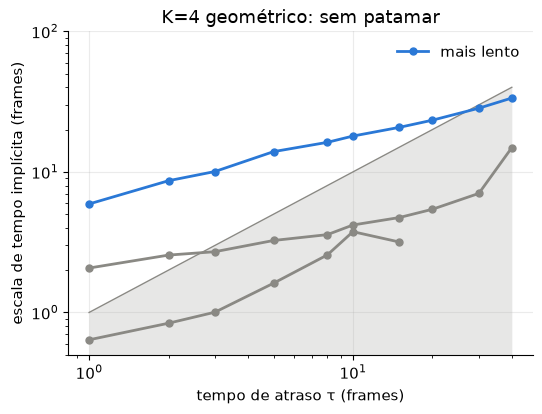

In [11]:
def eixo_its(ax, lags, titulo):
    ax.fill_between(lags, 0.5, lags, color=CINZA, alpha=0.2, lw=0)
    ax.plot(lags, lags, color=CINZA, lw=1)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("tempo de atraso τ (frames)")
    ax.set_ylabel("escala de tempo implícita (frames)")
    ax.set_title(titulo)


fig, ax = plt.subplots(figsize=(6, 4.2))
eixo_its(ax, LAGS, "K=4 geométrico: sem patamar")
for p in range(K - 1):
    ax.plot(LAGS, its_k4[:, p], "o-", ms=5, color=CORES[0] if p == 0 else CINZA,
            label="mais lento" if p == 0 else None)
ax.set_ylim(0.5, 100)
ax.legend(frameon=False)
fig.savefig(FIGS / "its_k4.png")
plt.show()

A escala mais lenta dos 4 estados não chega a patamar: cresce continuamente
com τ. Pelo critério cinético, **a partição K=4 não é markoviana** — dentro de
pelo menos um dos estados geométricos há regiões entre as quais a molécula
transita devagar, e a fronteira geométrica corta o processo lento em vez de
separá-lo.

## 3. Quantos processos lentos a trajetória tem?

Em vez de perguntar "qual K", a abordagem de modelos de estado de Markov
inverte a ordem: primeiro divide o espaço em muitos **microestados** pequenos
(aqui, K = 20 e K = 40 com a mesma variante `corda`), que resolvem a geometria
com folga; depois conta quantos processos lentos o espectro de T(τ) tem. Com
*n* processos claramente mais lentos que o resto, há *n* + 1 conjuntos
metaestáveis.

Incerteza: `bootstrap_timescales` reamostra 10 blocos contíguos da trajetória
somando as matrizes de contagem de cada bloco — sem inventar transições nas
emendas.

In [12]:
micro = {Km: best_of(X5, Km, n_init=20) for Km in (20, 40)}
its_micro = {Km: kin.implied_timescales(r.labels, LAGS, Km) for Km, r in micro.items()}

LAG_REF = 10
linhas, boot_micro = [], {}
for Km, r in micro.items():
    b = kin.bootstrap_timescales(r.labels, LAG_REF, Km, n_blocks=10, n_boot=500)
    boot_micro[Km] = b
    t_ref = kin.implied_timescales(r.labels, [LAG_REF], Km)[0]
    for p in range(3):
        lo, hi = np.nanpercentile(b[:, p], [2.5, 97.5])
        linhas.append({"K micro": Km, "processo": p + 1, "t (frames)": t_ref[p],
                       "IC95 inf": lo, "IC95 sup": hi, "t (ps)": t_ref[p] * DT_PS})
tab_its = pd.DataFrame(linhas)
print(f"τ = {LAG_REF} frames ({LAG_REF * DT_PS:.0f} ps)")
tab_its.round(1)

τ = 10 frames (100 ps)


,K micro,processo,t (frames),IC95 inf,IC95 sup,t (ps)
0,20,1,31.0,20.7,48.7,310.2
1,20,2,14.2,10.2,19.2,142.4
2,20,3,8.3,6.8,11.7,83.1
3,40,1,33.7,23.9,57.1,336.5
4,40,2,16.0,12.9,23.1,160.4
5,40,3,9.6,8.7,13.3,96.1


In [13]:
for Km, b in boot_micro.items():
    razao = b[:, 0] / b[:, 1]
    lo, hi = np.percentile(razao, [2.5, 97.5])
    print(f"K micro = {Km}: razão t1/t2 = {np.median(razao):.2f}  (IC95 {lo:.2f} – {hi:.2f})")

K micro = 20: razão t1/t2 = 2.14  (IC95 1.33 – 3.26)
K micro = 40: razão t1/t2 = 2.03  (IC95 1.36 – 2.87)


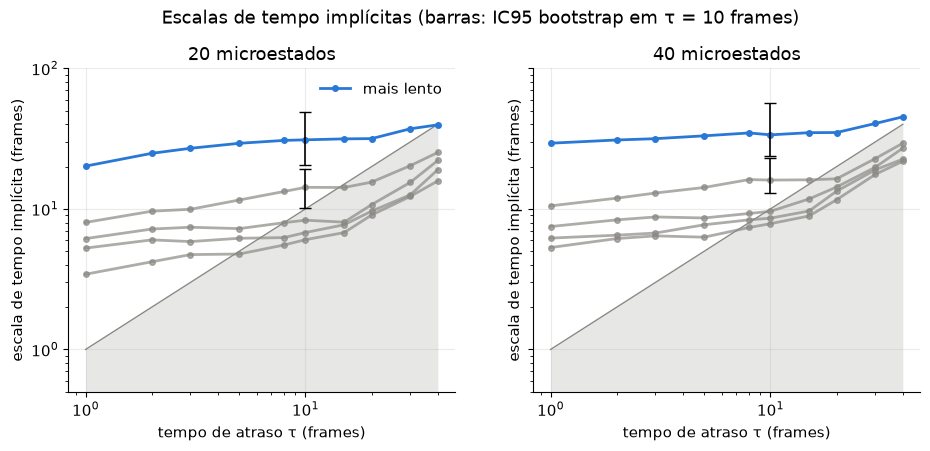

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (Km, its) in zip(axes, its_micro.items()):
    eixo_its(ax, LAGS, f"{Km} microestados")
    for p in range(5):
        ax.plot(LAGS, its[:, p], "o-", ms=4, color=CORES[0] if p == 0 else CINZA,
                alpha=1 if p == 0 else 0.7, label="mais lento" if p == 0 else None)
    b = boot_micro[Km]
    for p in range(2):
        lo, hi = np.nanpercentile(b[:, p], [2.5, 97.5])
        t = its[list(LAGS).index(LAG_REF), p]
        ax.errorbar(LAG_REF, t, yerr=[[t - lo], [hi - t]], fmt="none", capsize=4,
                    color="black", lw=1.2)
    ax.set_ylim(0.5, 100)
axes[0].legend(frameon=False)
fig.suptitle("Escalas de tempo implícitas (barras: IC95 bootstrap em τ = 10 frames)", y=1.02)
fig.savefig(FIGS / "its_microestados.png")
plt.show()

Com microestados finos a escala mais lenta varia muito menos com τ do que com
K=4 (com 40 microestados, quase nada entre τ = 1 e τ = 20), e os valores com 20
e 40 microestados são compatíveis entre si em τ = 10. É
**um processo claramente separado dos demais**: os intervalos de confiança do
primeiro e do segundo não se sobrepõem. O segundo, por outro lado, não se
destaca com clareza do contínuo de processos mais rápidos.

Nos maiores τ as curvas voltam a subir; ali τ já é comparável à própria escala
lenta, e 2000 frames contêm poucas janelas independentes desse tamanho — é
limite de estatística, não de física.

## 4. O que é o processo lento?

`spectral_split` divide os 40 microestados em dois macroestados pelo sinal do
autovetor do processo mais lento (a versão de dois estados do PCCA). A
fronteira cai onde a dinâmica é mais lenta, sem olhar para a geometria.

In [15]:
r40 = micro[40]
macro = kin.spectral_split(r40.labels, LAG_REF, 40)[r40.labels]
tem_L = (X5[:, 0::2] > 0).any(axis=1)

print("populações dos macroestados:", np.bincount(macro))
print(f"concordância entre o macroestado 1 e 'algum resíduo em α_L (φ > 0)': "
      f"{np.mean(macro == tem_L):.1%}")
fracL = pd.DataFrame({f"macro {m}": (X5[macro == m][:, 0::2] > 0).mean(0) for m in (0, 1)},
                     index=RESIDUOS)
fracL.round(2)

populações dos macroestados: [1246  754]
concordância entre o macroestado 1 e 'algum resíduo em α_L (φ > 0)': 90.0%


,macro 0,macro 1
Ala1,0.03,0.11
Ala2,0.02,0.43
Ala3,0.00,0.00
Ala4,0.00,0.00
Ala5,0.00,0.80
Ala6,0.10,0.02


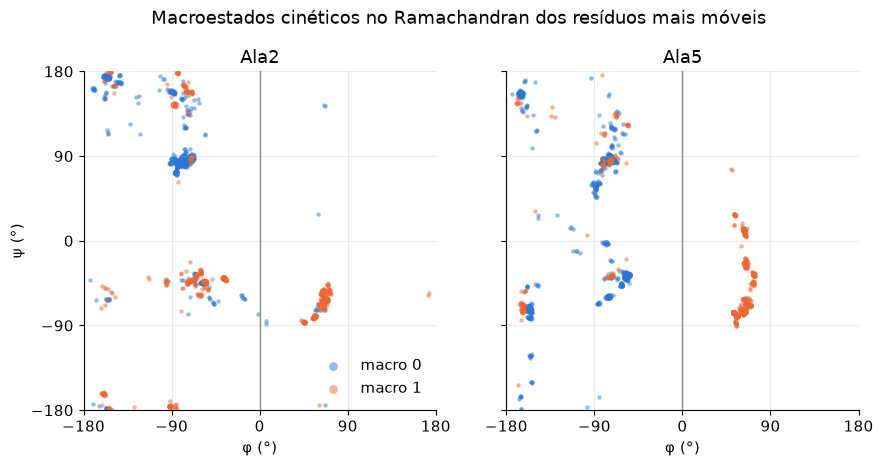

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4), sharey=True)
for ax, res in zip(axes, (2, 5)):
    phi, psi = X5[:, 2 * (res - 1)], X5[:, 2 * (res - 1) + 1]
    for m, cor, rot in ((0, CORES[0], "macro 0"), (1, CORES[1], "macro 1")):
        sel = macro == m
        ax.scatter(phi[sel], psi[sel], s=10, color=cor, alpha=0.5, lw=0, label=rot)
    ax.axvline(0, color=CINZA, lw=1)
    ax.set(xlim=(-180, 180), ylim=(-180, 180), xticks=range(-180, 181, 90),
           yticks=range(-180, 181, 90), xlabel="φ (°)", title=f"Ala{res}")
axes[0].set_ylabel("ψ (°)")
axes[0].legend(frameon=False, markerscale=2)
fig.suptitle("Macroestados cinéticos no Ramachandran dos resíduos mais móveis", y=1.02)
fig.savefig(FIGS / "macroestados_alfaL.png")
plt.show()

In [17]:
# Onde ficam os 4 estados geométricos em relação aos 2 macroestados cinéticos
pd.crosstab(pd.Series([f"{i} {nomes[i]}" for i in lab5], name="estado K=4"),
            pd.Series(macro, name="macroestado"), normalize="index").round(2)

macroestado,0,1
estado K=4,,
0 PPPβPP,0.76,0.24
1 PPPααP,0.94,0.06
2 PLPβLα,0.03,0.97
3 ββPβββ,0.89,0.11


In [18]:
# Os dois macroestados, tomados como partição, são markovianos?
its_macro = kin.implied_timescales(macro, LAGS, 2)[:, 0]
pd.DataFrame({"τ (frames)": LAGS, "t1 macro (frames)": its_macro,
              "t1 40 micro (frames)": its_micro[40][:, 0]}).round(1)

,τ (frames),t1 macro (frames),t1 40 micro (frames)
0,1,13.5,29.3
1,2,15.4,30.9
2,3,17.6,31.6
3,5,21.2,33.1
4,8,25.5,34.7
5,10,26.1,33.7
6,15,28.0,34.9
7,20,29.2,35.0
8,30,32.9,40.5
9,40,34.4,45.2


O processo lento é a **entrada e saída de resíduos na região α_L** (φ > 0),
sobretudo em Ala2 e Ala5: o macroestado 1 é, na maior parte dos frames, o
conjunto de conformações com algum resíduo em α_L, e o macroestado 0 o
conjunto sem nenhum. Faz sentido físico: mudar o sinal de φ exige cruzar a
barreira mais alta do mapa de Ramachandran da alanina, e é a transição mais
lenta conhecida já no dipeptídeo de alanina.

Dois cuidados para o relatório:

- **os dois macroestados não formam, sozinhos, um modelo markoviano a 10 ps**:
  tomados como partição, a sua escala só alcança o valor dos microestados em τ
  longos. O que os dados sustentam é mais modesto: o modelo de microestados tem
  um processo lento resolvido, e o autovetor desse processo separa as
  conformações com e sem α_L;
- dos 4 estados geométricos, só o estado 2 (o único com resíduos em α_L) corresponde a um
  macroestado cinético, o que tem α_L. Os outros três dividem o macroestado
  sem α_L por fronteiras geométricas que a dinâmica cruza depressa, e o
  estado 0 ainda tem cerca de um quarto dos seus frames do outro lado da
  fronteira lenta. Isso explica a falta de patamar na §2.2: a partição K=4
  gasta três das suas quatro divisões em processos rápidos.

## 5. A trajetória de 300 K

### 5.1 KNN treinado a 500 K (tarefa opcional 11)

O KNN usa a imersão (cos θ, sin θ) dos 12 diedros — a mesma geometria da
variante `corda`. Rodá-lo nos ângulos crus contradiria o notebook 02: −179° e
179° ficariam longe um do outro.

Antes de interpretar as previsões, é preciso saber se os frames de 300 K estão
**dentro** da região amostrada a 500 K; se não estiverem, o KNN está
extrapolando.

In [19]:
def imersao(X):
    t = np.radians(X)
    return np.hstack([np.cos(t), np.sin(t)])

E5, E3 = imersao(X5), imersao(X3)
d_300 = NearestNeighbors(n_neighbors=1).fit(E5).kneighbors(E3)[0][:, 0]
d_500 = NearestNeighbors(n_neighbors=2).fit(E5).kneighbors(E5)[0][:, 1]
print("distância ao vizinho mais próximo entre os frames de 500 K:")
print(f"  frames de 300 K: mediana {np.median(d_300):.3f}, percentil 90 {np.percentile(d_300, 90):.3f}")
print(f"  frames de 500 K: mediana {np.median(d_500):.3f}, percentil 90 {np.percentile(d_500, 90):.3f}")

distância ao vizinho mais próximo entre os frames de 500 K:
  frames de 300 K: mediana 0.042, percentil 90 0.057
  frames de 500 K: mediana 0.044, percentil 90 0.075


In [20]:
pred = {k_nn: KNeighborsClassifier(n_neighbors=k_nn).fit(E5, lab5).predict(E3)
        for k_nn in (1, 5, 15)}
tab_knn = pd.DataFrame({"nome": nomes, "população 500 K": pops,
                        **{f"300 K, KNN k={k_nn}": kin.populations(p, K) for k_nn, p in pred.items()}})
tab_knn.round(3)

,nome,população 500 K,"300 K, KNN k=1","300 K, KNN k=5","300 K, KNN k=15"
0,PPPβPP,0.290,0.013,0.013,0.013
1,PPPααP,0.288,0.966,0.966,0.965
2,PLPβLα,0.283,0.000,0.000,0.000
3,ββPβββ,0.140,0.021,0.021,0.022


Os frames de 300 K estão tão perto dos de 500 K quanto os de 500 K estão entre
si: não há extrapolação. Mesmo assim, o KNN (com qualquer número de vizinhos)
põe quase toda a trajetória de 300 K **num único estado** de 500 K. A partição
aprendida a 500 K é grossa demais para 300 K: toda a variedade conformacional
de 300 K cabe dentro de um dos estados de alta temperatura.

### 5.2 Agrupamento próprio a 300 K

In [21]:
can3 = canonical_states(X3, k=K)
lab3 = can3.labels
nomes3 = [state_name(c) for c in can3.centers]
dw3 = kin.dwell_times(lab3, K, drop_censored=False)
pd.DataFrame({
    "nome": nomes3,
    "população": kin.populations(lab3, K),
    "visitas": [len(d) for d in dw3],
    "residência média (frames)": [d.mean() for d in dw3],
    "primeiro frame": [np.flatnonzero(lab3 == s)[0] for s in range(K)],
    "último frame": [np.flatnonzero(lab3 == s)[-1] for s in range(K)],
}).round(2)

,nome,população,visitas,residência média (frames),primeiro frame,último frame
0,αPPααβ,0.35,89,3.96,99,675
1,PPPααβ,0.26,129,2.00,0,998
2,PPPβαP,0.26,128,2.01,2,999
3,αPPβαP,0.13,87,1.53,102,676


In [22]:
its_300 = kin.implied_timescales(lab3, LAGS, K)
pd.DataFrame(its_300, index=pd.Index(LAGS, name="τ (frames)"),
             columns=[f"t{i} (frames)" for i in range(1, K)]).round(1)

,t1 (frames),t2 (frames),t3 (frames)
τ (frames),,,
1,49.4,0.4,0.2
2,48.9,0.8,0.6
3,48.3,1.7,NaN
5,54.0,1.9,NaN
8,66.8,3.4,2.2
10,72.4,3.7,3.5
15,80.3,7.0,NaN
20,84.0,10.2,NaN
30,86.4,15.0,NaN


In [23]:
# Ala1 em α_R a 300 K: fração por janela de 50 frames (0,5 ns)
ala1_alfa = ramachandran_region(X3[:, 0], X3[:, 1]) == "α"
print("fração de frames com Ala1 em α_R, por janela de 50 frames:")
print(ala1_alfa.reshape(-1, 50).mean(axis=1).round(2))
dentro = ala1_alfa[99:677].mean()
fora = np.r_[ala1_alfa[:99], ala1_alfa[677:]].mean()
print(f"entre os frames 99 e 676: {dentro:.0%};  fora dessa janela: {fora:.0%}")

fração de frames com Ala1 em α_R, por janela de 50 frames:
[0.   0.02 1.   0.82 1.   0.94 0.98 0.98 1.   1.   1.   0.14 0.24 0.54
 0.   0.   0.   0.   0.   0.  ]
entre os frames 99 e 676: 84%;  fora dessa janela: 0%


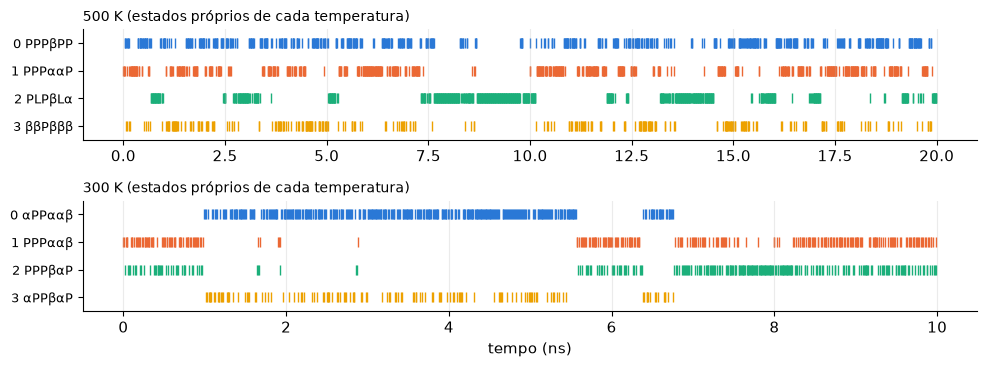

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(10, 3.8), sharex=False)
for ax, lab, nms, temp in ((axes[0], lab5, nomes, "500 K"), (axes[1], lab3, nomes3, "300 K")):
    t_ns = np.arange(len(lab)) * DT_PS / 1000
    for s in range(K):
        sel = lab == s
        ax.scatter(t_ns[sel], np.full(sel.sum(), s), marker="|", s=60, color=CORES[s], lw=1)
    ax.set_yticks(range(K), [f"{s} {n}" for s, n in enumerate(nms)], fontsize=9)
    ax.set_ylim(K - 0.5, -0.5)
    ax.set_title(f"{temp} (estados próprios de cada temperatura)", fontsize=10, loc="left")
    ax.grid(axis="y", visible=False)
axes[1].set_xlabel("tempo (ns)")
fig.tight_layout()
fig.savefig(FIGS / "rotulos_tempo.png")
plt.show()

A 300 K praticamente não há α_L (tabela da §0), então o processo lento de
500 K não existe aqui. Os 4 estados próprios de 300 K trocam entre si com
frequência, mas não são amostrados de forma homogênea no tempo: os dois
estados com Ala1 em α_R só aparecem num trecho do meio da trajetória. Ala1
entra em α_R por volta de 1 ns e sai de vez por volta de 6,8 ns, com
algumas idas e vindas no fim — na prática, **um único evento lento em 10 ns**.
A escala mais lenta da tabela acima não tem patamar e, estimada a partir de um
evento, não deve ser citada como taxa.

Conclusão honesta: **10 ns a 300 K não equilibram os estados desta
temperatura.** Não dá para estimar ΔG de equilíbrio nem testar, pelo critério
cinético, se os estados de 300 K são "mais separados" que os de 500 K. O que se
pode afirmar é qualitativo: a 300 K a molécula fica confinada numa região que
a 500 K é um único estado, sem acesso a α_L, e a sua dinâmica lenta é outra.

## 6. Resumo e resposta à Questão 7

In [25]:
b40 = boot_micro[40]
lo1, hi1 = np.nanpercentile(b40[:, 0], [2.5, 97.5])
t40 = kin.implied_timescales(micro[40].labels, [LAG_REF], 40)[0]
print(f"K=4 geométrico: {n_minimos} mínimos locais em 50 sementes; sem patamar nas escalas implícitas")
print(f"  t1(τ=1) = {its_k4[0, 0]:.1f} frames  ->  t1(τ=40) = {its_k4[-1, 0]:.1f} frames")
print(f"40 microestados, τ = {LAG_REF} frames: t1 = {t40[0]:.1f} frames "
      f"({t40[0] * DT_PS / 1000:.2f} ns, IC95 {lo1 * DT_PS / 1000:.2f}–{hi1 * DT_PS / 1000:.2f} ns); "
      f"t2 = {t40[1]:.1f} frames")
print(f"processo lento <-> α_L: concordância {np.mean(macro == tem_L):.1%}")
print(f"300 K: {kin.populations(pred[15], K).max():.1%} dos frames num único estado de 500 K (KNN k=15)")

K=4 geométrico: 43 mínimos locais em 50 sementes; sem patamar nas escalas implícitas
  t1(τ=1) = 5.9 frames  ->  t1(τ=40) = 33.6 frames
40 microestados, τ = 10 frames: t1 = 33.7 frames (0.34 ns, IC95 0.24–0.57 ns); t2 = 16.0 frames
processo lento <-> α_L: concordância 90.0%
300 K: 96.5% dos frames num único estado de 500 K (KNN k=15)


**Questão 7 — (1) qual conjunto de features funciona melhor, e (2) quantos
estados metaestáveis a molécula tem?**

*(1) Features.* Os diedros, tratados como periódicos. Raio de giro e RMSD
resumem a conformação em dois números que não distinguem conformações
diferentes com a mesma compactação, e o RMSD depende da escolha arbitrária do
frame de referência. Os diedros descrevem diretamente os graus de liberdade que
mudam. Mas precisam ser tratados como periódicos: com a média aritmética do
material de referência o K-means entra em ciclo limite com frequência, e só a
variante coerente (`corda`, notebook 02) converge sempre com o objetivo
descendo a cada passo.

*(2) Número de estados.* Depende do critério, e essa é a resposta:

- **pelo critério geométrico, o número não é bem definido.** O cotovelo é
  fraco, métodos diferentes discordam (ARI no notebook 02), e mesmo para K=4
  fixo a mesma variante chega a dezenas de partições diferentes conforme a
  semente;
- **pelo critério cinético, a trajetória de 500 K tem um processo lento
  resolvido**, na escala de algumas centenas de ps, claramente separado dos
  demais. Pela leitura usual de modelos de Markov, isso corresponde a **dois
  conjuntos metaestáveis**: conformações com e sem resíduos em α_L. Um terceiro
  não é resolvido com 20 ns de trajetória;
- **os 4 estados do K-means geométrico não são metaestáveis** nesse sentido:
  as suas escalas não têm patamar, e só um deles coincide com um dos conjuntos
  cinéticos.

Ressalvas: a molécula tem uma ligação *cis* entre Ala3 e Ala4 em todas as
trajetórias fornecidas (§0), e a trajetória de 300 K é curta demais para
equilibrar os seus próprios estados (§5.2).